# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


## Marvel vs DC IMDb Data Analysis

This project explores relationships between movie ratings and different features seuch as votes, runtime, genre, and category (Marvel vs DC)

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv("Marvel_DC_imdb.csv")

In [35]:
df = df.drop(columns=['Unnamed: 0'])

In [36]:
df.columns = df.columns.str.strip()

In [37]:
df['IMDB_Score'] = pd.to_numeric(df['IMDB_Score'], errors='coerce')

In [45]:
df.head()

,Movie,Year,Genre,RunTime,Rating,Director,Actor,Description,IMDB_Score,Metascore,Votes,USA_Gross,Category
0,Eternals,(2021),"Action,Adventure,Drama",NaN,NaN,ChloéZhao,"AngelinaJolie,GemmaChan,RichardMadden,BarryKeo...","The saga of the Eternals, a race of immortal b...",NaN,NaN,NaN,NaN,Marvel
1,Loki,(2021– ),"Action,Adventure,Fantasy",NaN,NaN,NaN,"TomHiddleston,OwenWilson,SophiaDiMartino,Richa...",A new Marvel chapter with Loki at its center.,NaN,NaN,NaN,NaN,Marvel
2,The Falcon and the Winter Soldier,(2021),"Action,Adventure,Drama",50.0,TV-14,NaN,"AnthonyMackie,SebastianStan,WyattRussell,ErinK...","Following the events of 'Avengers: Endgame,' S...",7.5,NaN,NaN,NaN,Marvel
3,WandaVision,(2021),"Action,Comedy,Drama",350.0,TV-PG,NaN,"ElizabethOlsen,PaulBettany,KathrynHahn,Teyonah...",Blends the style of classic sitcoms with the M...,8.1,NaN,NaN,NaN,Marvel
4,Spider-Man: No Way Home,(2021),"Action,Adventure,Sci-Fi",NaN,NaN,JonWatts,"AngourieRice,TomHolland,Zendaya,MarisaTomei",A continuation of Spider-Man: Far From Home.,NaN,NaN,NaN,NaN,Marvel


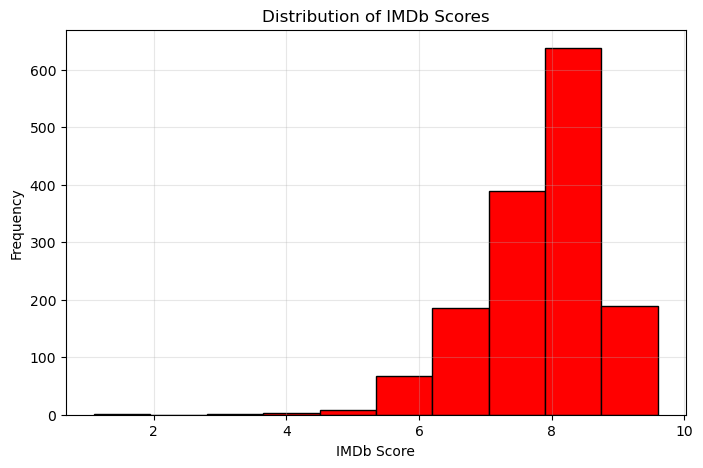

In [38]:
plt.figure(figsize=(8,5))
plt.hist(df['IMDB_Score'].dropna(), bins=10, color='red', edgecolor='black')

plt.title("Distribution of IMDb Scores")
plt.xlabel('IMDb Score')
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()

### IMDb Distribution
This histogram shows how IMDb scores are spread across all the movies in the dataset. Most of the ratings fall between about 6 and 9, so overall these movies are generally rated pretty well. There aren’t many really low scores, which means badly rated movies are kind of rare here. So overall, the data leans heavily toward positive ratings.

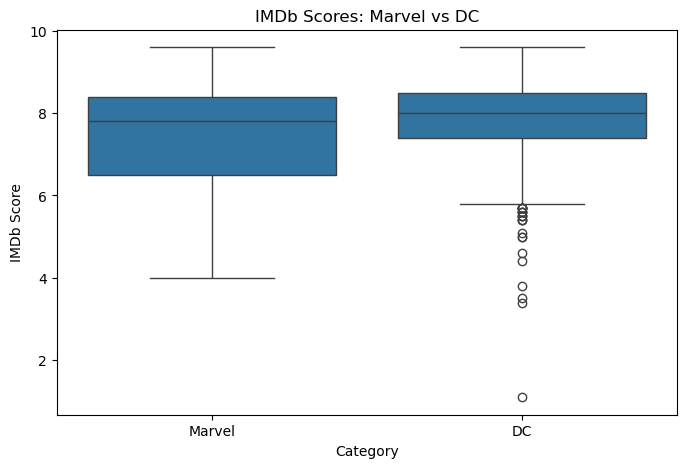

In [39]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='Category', y='IMDB_Score', data=df)

plt.title("IMDb Scores: Marvel vs DC")
plt.xlabel("Category")
plt.ylabel("IMDb Score")

plt.show()

### Marvel vs DC

This boxplot compares IMDb scores between Marvel and DC movies. Both of them have pretty similar average ratings, usually around the 7 to 8 range. DC seems to have a bit more variation, especially with some lower outliers. So while both are rated pretty similarly overall, DC movies seem a little more hit-or-miss.

In [40]:
df['Votes'] = df['Votes'].astype(str).replace(',', '', regex=False)
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

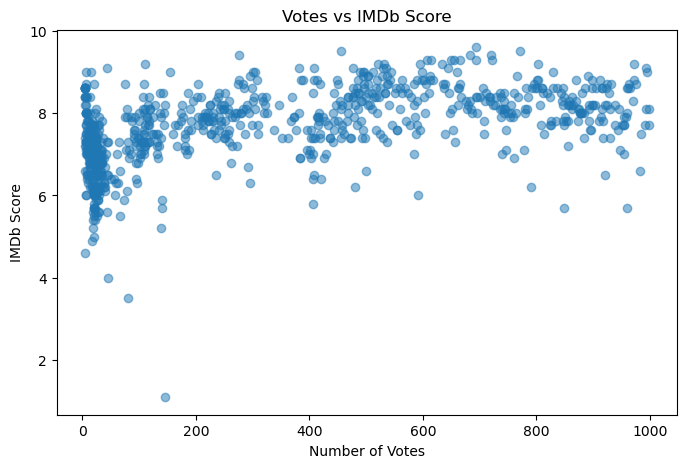

In [41]:
plt.figure(figsize=(8,5))
plt.scatter(df['Votes'], df['IMDB_Score'], alpha=0.5)

plt.title("Votes vs IMDb Score")
plt.xlabel("Number of Votes")
plt.ylabel("IMDb Score")

plt.show()

### Votes vs IMDb Score

This scatterplot shows how the number of votes compares to IMDb scores. There’s a slight trend where movies with more votes tend to have decent ratings, but it’s not super strong since the points are pretty spread out. Most of the heavily voted movies still sit around the 7–9 range. So popularity helps a little, but it doesn’t guarantee a higher rating.

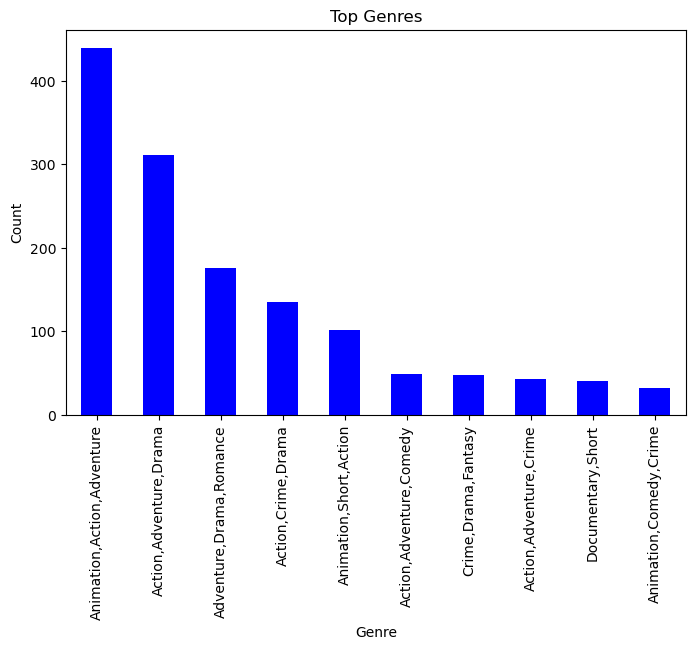

In [42]:
df['Genre'].value_counts().head(10).plot(kind='bar', figsize=(8,5), color='blue')

plt.title("Top Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

### Top Genres

This bar chart shows the most common genres in the dataset. Action and adventure clearly dominate, which makes sense for Marvel and DC movies. There are some other genres mixed in like drama and comedy, but they show up a lot less. Overall, this confirms that most of these movies follow that typical action-heavy superhero style.

In [43]:
df['RunTime'] = df['RunTime'].str.replace(' min', '', regex=False)
df['RunTime'] = pd.to_numeric(df['RunTime'], errors='coerce')

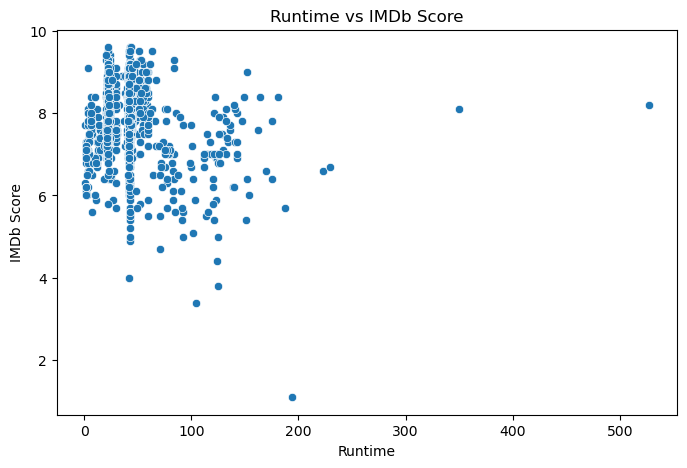

In [44]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='RunTime', y='IMDB_Score', data=df)

plt.title("Runtime vs IMDb Score")
plt.xlabel("Runtime")
plt.ylabel("IMDb Score")

plt.show()

### Runtime vs IMDb Score

This scatterplot looks at how runtime relates to IMDb scores. Most movies fall somewhere between 50 and 150 minutes, and their ratings stay in a similar range. There’s no clear pattern showing that longer movies are better or worse. So runtime doesn’t really seem to have much impact on how movies are rated.

### Final Conclusion

Looking at everything together, both Marvel and DC movies tend to land in a similar rating range, with most scores falling between 6 and 9. More votes don’t necessarily mean a higher rating, and runtime doesn’t seem to play a big role either. The dataset is heavily focused on action and adventure, which fits the superhero theme. Overall, both franchises perform pretty similarly, but DC shows a bit more inconsistency in how its movies are rated.